## Learning Graph buidling from LangGraph

In [107]:
import os
from typing import TypedDict
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage, HumanMessage
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
# from langgraph.

from IPython.display import Image, display

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [88]:
# Defining llm as chatgroq

# llm = ChatGroq(model="qwen/qwen3-32b",max_tokens=1024)
llm = ChatGroq(model="qwen/qwen3-32b")

# testing the model     
# result = llm.invoke("What is the capital of France?")
# print(result.content)

In [3]:
# defining functions used as nodes in the graph

def llm_node(query: MessagesState):
    input_message = query['messages']
    print(f"input message to llm node: {query}")
    result = llm.invoke(input_message)
    return {"messages": [result]}

def token_count_node(query: MessagesState):
    print(f"input message to token count node: {query}")
    input_message = query['messages'][-1].content
    # print(f"input message to token count node: {input_message}")
    result = len(input_message.split())
    return {"messages": [f"Token count: {result}"]}

In [4]:
# creating the graph, adding nodes and edges
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("text_generation", llm_node)
graph_builder.add_node("token_count", token_count_node)

graph_builder.add_edge(START, "text_generation")
graph_builder.add_edge("text_generation", "token_count")
graph_builder.add_edge("token_count", END)

app = graph_builder.compile()

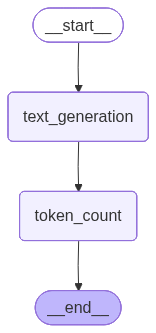

In [5]:
# Visualizing the graph
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
# Invoking the graph

result = app.invoke({"messages":["what is INR vs USD today?"]})
# result = app.invoke("what is the capital of Germany?")
print(result)

input message to llm node: {'messages': [HumanMessage(content='what is INR vs USD today?', additional_kwargs={}, response_metadata={}, id='19889713-7b70-452f-8d80-782dfdf4b1d0')]}
input message to token count node: {'messages': [HumanMessage(content='what is INR vs USD today?', additional_kwargs={}, response_metadata={}, id='19889713-7b70-452f-8d80-782dfdf4b1d0'), AIMessage(content='<think>\nOkay, the user is asking for the current exchange rate between the Indian Rupee (INR) and the US Dollar (USD). Let me start by recalling the latest exchange rates I have. I think the rate fluctuates a lot based on market conditions, so I need to check if my data is up-to-date. \n\nFirst, I\'ll check my knowledge cutoff date. The user mentioned "today," but since I don\'t have real-time data, I should inform them about that. My last update was July 2024, so any rates I provide might not be current. The last time I checked, the INR to USD rate was around 84.50, but that might have changed.\n\nI shoul

In [8]:
result['messages']

[HumanMessage(content='what is INR vs USD today?', additional_kwargs={}, response_metadata={}, id='19889713-7b70-452f-8d80-782dfdf4b1d0'),
 AIMessage(content='<think>\nOkay, the user is asking for the current exchange rate between the Indian Rupee (INR) and the US Dollar (USD). Let me start by recalling the latest exchange rates I have. I think the rate fluctuates a lot based on market conditions, so I need to check if my data is up-to-date. \n\nFirst, I\'ll check my knowledge cutoff date. The user mentioned "today," but since I don\'t have real-time data, I should inform them about that. My last update was July 2024, so any rates I provide might not be current. The last time I checked, the INR to USD rate was around 84.50, but that might have changed.\n\nI should explain that exchange rates are influenced by factors like supply and demand, economic indicators, and geopolitical events. Maybe the user is converting money for travel, business, or investment. It\'s important to mention th

## Graph 2

In [9]:
# defining message schema
class SimpleState(TypedDict):
    query: str
    result: str


# Defining nodes
def llm_node_without_state(state: SimpleState):
    print(f"state of the graph at llm node: {state}")
    result = llm.invoke(state['query'])
    return {"result": result}

def token_count_node_without_state(state: SimpleState):
    print(f"state of the graph at token count node: {state}")
    result = len(state['result'].content.split())
    return {"result" : f"Token Count: {result}"}

In [10]:
# Creating graph with simple input state

graph_builder_2 = StateGraph(SimpleState)
graph_builder_2.add_node("llm_node", llm_node_without_state)
graph_builder_2.add_node("token_count_node", token_count_node_without_state)

graph_builder_2.add_edge(START, "llm_node")
graph_builder_2.add_edge("llm_node", "token_count_node")
graph_builder_2.add_edge("token_count_node", END)

app_2 = graph_builder_2.compile()

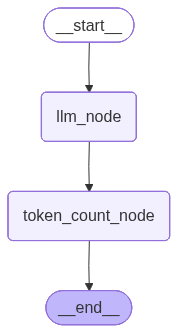

In [11]:
# visualizing the graph

display(Image(app_2.get_graph().draw_mermaid_png()))

In [12]:
# invoking the graph 2
result_2 = app_2.invoke({"query": "What are the records of Sachin Tendulkar in international cricket?"})
print(result_2)

state of the graph at llm node: {'query': 'What are the records of Sachin Tendulkar in international cricket?'}
state of the graph at token count node: {'query': 'What are the records of Sachin Tendulkar in international cricket?', 'result': AIMessage(content='<think>\nOkay, so I need to figure out the records held by Sachin Tendulkar in international cricket. Let me start by recalling what I know about him. He\'s often called the "Little Master" and has been a key player for India for a long time. I remember he has a lot of records, but I\'m not sure about the exact numbers.\n\nFirst, he\'s the highest run-scorer in international cricket, right? I think he played both Tests and ODIs. Wait, in ODIs, he has the most runs, and in Tests too. Let me check that. I believe he has over 18,000 runs in Tests and over 18,000 in ODIs combined. But wait, the user might be asking about individual records. Maybe the highest number of centuries in both formats. I think he has over 100 centuries in to

## Graph with conditonal edge

In [3]:
search_tool = DuckDuckGoSearchRun()

tools = [search_tool]
llm = ChatGroq(model="qwen/qwen3-32b")
llm_with_tool = llm.bind_tools(tools)

In [4]:
# creatig nodes
def llm_node(state: MessagesState):
    print(f"state of the graph at llm node: {state}")
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

def search_node(state: MessagesState):
    print(f"state of the graph at search node: {state}")
    search_result = search_tool.invoke(state["messages"][-1].content)
    augmented_message = state["messages"] + [SystemMessage(content=f"Use following search result to answer the query:\n{search_result}")]
    result = llm_with_tool.invoke(augmented_message)
    return {"messages": [result]}

# router function 
def router_function(state: MessagesState):
    print(f"state of the graph at router node: {state}")
    last_message = state["messages"][-1].content
    
    CLASSIFICATION_PROMPT = f"""Does the following query require searching the internet for 
current/real-time information, recent events, live data or specific URLs? 
Answer only YES or NO.

Query: {last_message}"""

    response = llm.invoke([HumanMessage(content=CLASSIFICATION_PROMPT)])

    if "YES" in response.content.strip().upper():
        return "search_node"
    else:
        return "llm_node"

In [5]:
# creating graph
graph_builder_3 = StateGraph(MessagesState)
graph_builder_3.add_node("llm_node", llm_node)
graph_builder_3.add_node("search_node", search_node)

graph_builder_3.add_conditional_edges(START, router_function, {"search_node": "search_node", "llm_node": "llm_node"})
graph_builder_3.add_edge("llm_node", END)
graph_builder_3.add_edge("search_node", END)

app_3 = graph_builder_3.compile()

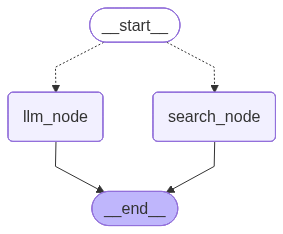

In [6]:
# visualizing the graph
display(Image(app_3.get_graph().draw_mermaid_png()))

In [13]:
answer = app_3.invoke({"messages": [HumanMessage(content="what is the current stock price of Apple ?")]})
print(answer)

state of the graph at router node: {'messages': [HumanMessage(content='what is the current stock price of Apple ?', additional_kwargs={}, response_metadata={}, id='3a831eed-0ed7-4523-b35c-157311bc8433')]}
state of the graph at search node: {'messages': [HumanMessage(content='what is the current stock price of Apple ?', additional_kwargs={}, response_metadata={}, id='3a831eed-0ed7-4523-b35c-157311bc8433')]}
{'messages': [HumanMessage(content='what is the current stock price of Apple ?', additional_kwargs={}, response_metadata={}, id='3a831eed-0ed7-4523-b35c-157311bc8433'), AIMessage(content='The current stock price of Apple (AAPL) is $293.32 USD, as of the most recent information provided. This price reflects a 2.05% increase over the past 24 hours.', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the current stock price of Apple. Let me check the information provided in the search results.\n\nLooking at the search results, there are a few mentions of the stock pr

In [14]:
print(answer['messages'][-1].content)

The current stock price of Apple (AAPL) is $293.32 USD, as of the most recent information provided. This price reflects a 2.05% increase over the past 24 hours.


## Graph with tool

In [89]:
# llm

# llm = ChatOpenAI(model="gpt-5-mini-2025-08-07", temperature=0.3)

In [90]:
# defining few tools

@tool
def sum_of_numbers(a: int, b: int) -> int:
    """
    This function takes two integers as input and returns their sum/addition.

    args:
        a (int): The first number to be added.
        b (int): The second number to be added.

    returns:
        int: The sum of the two input numbers.
    """
    return a + b


@tool
def difference_of_numbers(a: int, b: int) -> int:
    """
    This function takes two integers as input and returns their difference/subtraction.

    args:
        a (int): The number from which to subtract.
        b (int): The number to be subtracted.

    returns:
        int: The difference of the two input numbers.
    """
    return a - b

@tool
def product_of_numbers(a: int, b: int) -> int:
    """
    This function takes two integers as input and returns their product/multiplication.

    args:
        a (int): The first number to be multiplied.
        b (int): The second number to be multiplied.

    returns:
        int: The product of the two input numbers.
    """
    return a * b


@tool
def quotient_of_numbers(a: int, b: int) -> float:   
    """
    This function takes two integers as input and returns their quotient/division.

    args:
        a (int): The dividend.
        b (int): The divisor.

    returns:
        float: The quotient of the two input numbers. If the divisor is zero, returns a string indicating that division by zero is not allowed.
    """
    if b == 0:
        return "Division by zero is not allowed."
    return a / b


search_tool = DuckDuckGoSearchRun()


In [91]:
# binding tools to llm

tools = [search_tool, sum_of_numbers, difference_of_numbers, product_of_numbers, quotient_of_numbers]
llm_with_tools_4 = llm.bind_tools(tools)

In [92]:
# res = llm_with_tools_4.invoke("What is the sum of 5 and 10?")
# res = llm_with_tools_4.invoke("What is the current value of INR against USD?")
# res = llm_with_tools_4.invoke("What is the current value of INR against USD and transform into paise?")
# print(res)

In [93]:
# res?\

In [94]:
# res.tool_calls

In [108]:
# defining node functions

def llm_node_4(state: MessagesState):
    """This node function takes the current state of the graph
and generates a response."""
    response = llm_with_tools_4.invoke(state['messages'])
    return {"messages": [response]}


tool_node_4 = ToolNode(tools)

In [111]:
graph_builder_4 = StateGraph(MessagesState)
graph_builder_4.add_node("llm_node", llm_node_4)
graph_builder_4.add_node("tool_node", tool_node_4)

graph_builder_4.add_edge(START, "llm_node")
graph_builder_4.add_conditional_edges("llm_node", tools_condition, {"tools": "tool_node", END: END})
graph_builder_4.add_edge("tool_node", "llm_node")

graph_4 = graph_builder_4.compile()


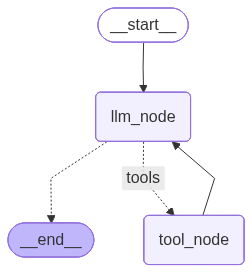

In [112]:
display(Image(graph_4.get_graph().draw_mermaid_png()))

In [113]:
# answer = graph_4.invoke({"messages": "what are the top 5 movies of all time?"})
# answer = graph_4.invoke({"messages": "who are the top 5 pro-wrestlers of all time?"})
# answer = graph_4.invoke({"messages": "what is the rate of INR vs USD today? Then multiply by 100 to convert to paise?"})
# answer = graph_4.invoke({"messages": "How old Narendra Modi is? Answer it in number of weeks."})
answer = graph_4.invoke({"messages": "what is the net wealth of Elon Musk? Transform the answer into Indian Rupees if it's in USD."})

In [114]:
answer

{'messages': [HumanMessage(content="what is the net wealth of Elon Musk? Transform the answer into Indian Rupees if it's in USD.", additional_kwargs={}, response_metadata={}, id='5af13801-88dd-4e96-9741-f4850dd95490'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for Elon Musk\'s net wealth and wants it converted to Indian Rupees if it\'s in USD. First, I need to find the current net worth of Elon Musk. Since this is a time-sensitive query, I should use the DuckDuckGo search tool to get the latest information. \n\nI\'ll start by calling the duckduckgo_search function with the query "Elon Musk net worth". That should give me the most recent figure. Once I have that, I need to check if the value is in USD. If it is, the next step is to convert it to Indian Rupees. \n\nTo do the conversion, I\'ll need the current exchange rate between USD and INR. I can use another DuckDuckGo search for "USD to INR exchange rate" to get the latest rate. After o

In [115]:
# print(answer['messages'][-1].content)

In [116]:
# answer['messages'][-1].tool_calls

In [117]:
for i in answer['messages']:
    i.pretty_print()

================================ Human Message =================================

what is the net wealth of Elon Musk? Transform the answer into Indian Rupees if it's in USD.
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (f6th1zfc4)
 Call ID: f6th1zfc4
  Args:
    query: Elon Musk net worth
================================= Tool Message =================================
Name: duckduckgo_search

5 days ago - Elon Musk is the wealthiest person in the world that’s been verified, with an estimated net worth of US$659 billion as of May 2026, according to the Bloomberg Billionaires Index, and $788 billion according to Forbes, primarily from his ownership stakes in SpaceX and Tesla. 7 hours ago - Elon Musk is the wealthiest person in the world that’s been verified, with an estimated net worth of US$659 billion as of May 2026, according to the Bloomberg Billionaires Index, and $788 billion according to Forbes, primarily from hi